# Introduction to Recurrent Neural Networks

## Our World in Sequence

Our world is fundamentally sequential. A movie is a series of 'shots' layered on top of each other, music is a series of notes, tomorrow's temperature is influenced by today's weather. Even the way you read sentences, ***'I went to the bank'***, there is context, if you were to read the words in isolation, they would make no sense.

Traditional feedforward neural networks, powerful as they are, suffer from a critical limitation: they have no memory. Each input is processed independently, in isolation from everything that came before. Using our example, ***' I washed my face at the bank'***, the FCNN will not know whether the word "bank" means a financial institution or the side of a river. The context—the sequence of words leading up to that moment is lost in FCNN.

This is exactly what recurrent neural networks were developed to do. RNNs possess a form of memory, allowing them to maintain information about previous inputs as they process new ones.



### What is a Recurrent Neural Network

RNNs are a type of neural network that feeds learned information back into the network using what we call hidden states, these hidden states are like internal memory that capture information from previous time steps and are then used in subsequent ones. The RNN is always updating this internal hidden state at every time step.

#### Key components of a RNN
Every RNN has three essential parts working together:
1. Input (x): The current piece of data being processed (like the current word in our sentence)
2. Hidden State (h): The network's memory-a summary of everything it has processed so far. This is what makes RNNs special. The hidden state gets updated at each step and carries forward.
3. Output (y): The prediction or result at the current step 

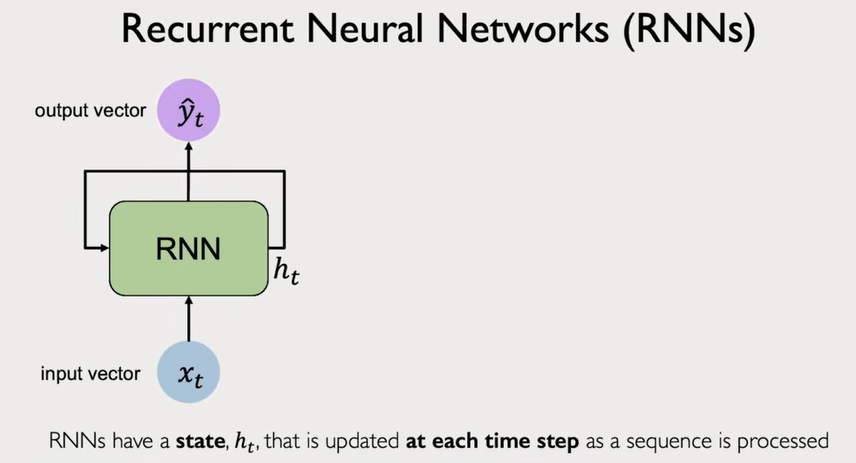


#### How RNNs work
Now imagine we are trying to predict the stock prices of Kengen from historical prices. The naive way of doing this would look something like this below. Where you are predicting tomorrow's price only from yesterday's value.

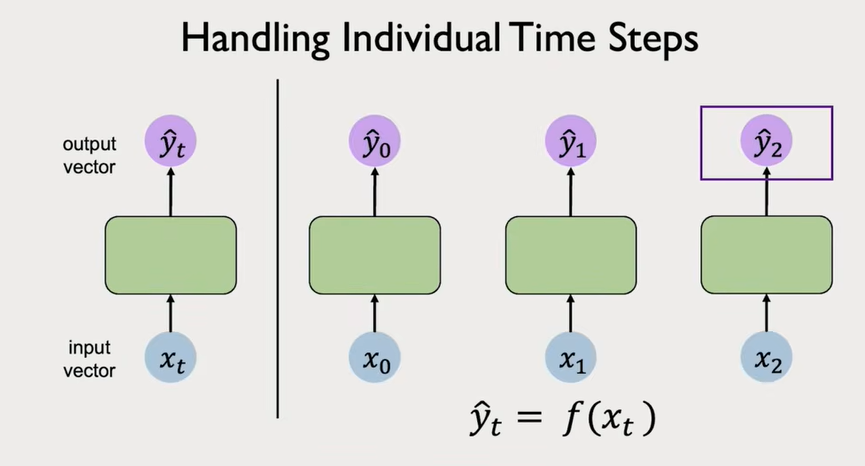

Unfortunately, this does not capture the temporal dependence usually seen with stock price data. How then do we relate these individual timesteps with each other? RNNs do this by introducing a special variable called the hidden state. What the hidden state does is, it links the internal computations from previous time steps, and allows the learned information from these computations to be passed along all timesteps in the network.


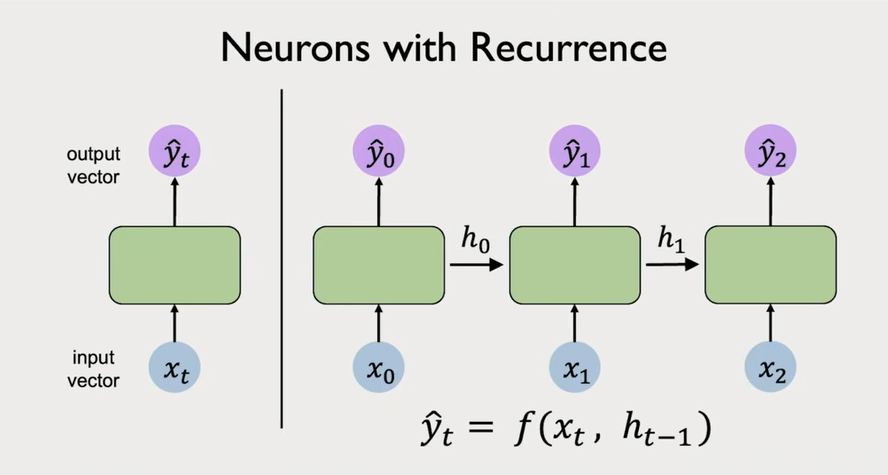

The RNN in short, goes through a recursive process where it takes the current input (x), looks at its previous hidden state (memory), calculates a weighted sum of the hidden state and input and applies an activation function to it (in our case I have used tanh, it can also be ReLU), produces a new hidden state (aka updates the memory at that time step)....

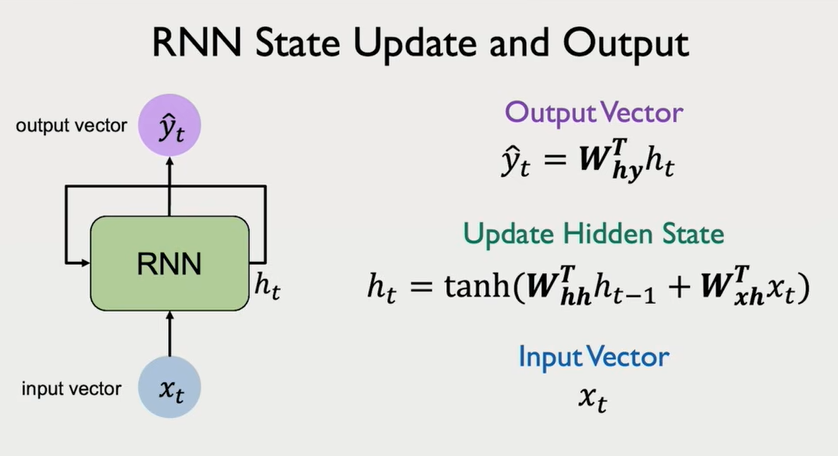


#### How RNNs learn: Backpropagation through time (BPTT)
BPTT works by extending the principle of regular backpropagation to handle sequential data. The key challenge is that in an RNN, the same network weights are reused at every time step, and each step's output depends on all previous steps through the hidden state. To train the network, we first perform a forward pass, processing the entire input sequence step by step while storing all the hidden states along the way. Once we reach the end and calculate the prediction error ( loss function), we then perform a backward pass that flows the error gradients backward through time - starting from the final step and moving back to the beginning. 

In short, we are trying to find the gradient of the loss function with respect to each weight at every time step (similar to traditional back propagation, but here the weights are the same across the time steps). These gradients accumulate as they flow backward through the unrolled network, and because the same weights are used at every time step, we sum up all the gradients across all time steps before making a single weight update.


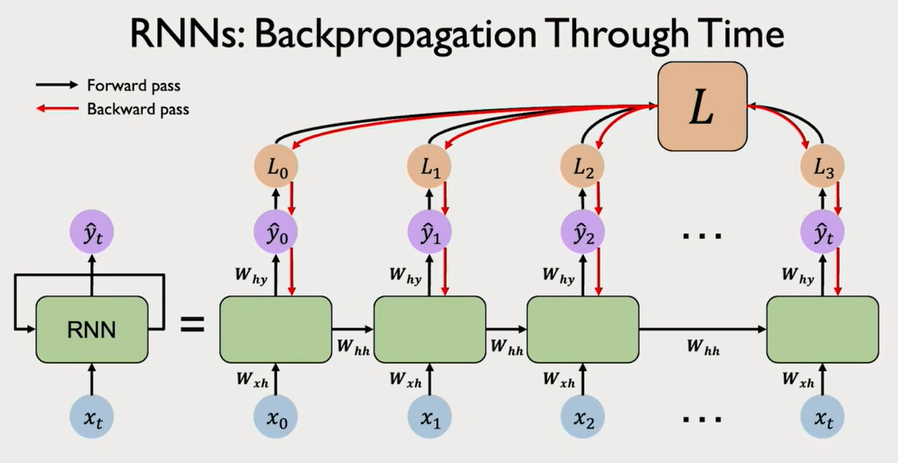


Let me try and make one thing clear, if you are understood the basic intuition of RNN, a question that you may have at this juncture is....if the same weights are passed on across each time step, why do we need backpropagation? Why not just calculate the loss with respect to the weight once? Let me try and use an example here so the point lands more clearly...

Understand that even though the weights are the same, the context in which they're applied is different at each time step, and those different contexts create different contributions to the final error.
Consider this example of predicting the next word in "The cat sat on the ___":

- At time step 1, the weights process "The" with an empty initial hidden state
- At time step 2, the same weights process "cat" but now with a hidden state that contains information about "The"
- At time step 3, the same weights process "sat" with a hidden state containing information about "The cat"
- At time step 4, the same weights process "on" with accumulated context from all previous words

The same weights are being used in different situations, with different inputs and different hidden states. So they contribute to the error in different ways at different times. When we perform BPTT, we're asking: "How did these weights contribute to the error across all the different times they were used?"

Perhaps at step 1, using weight W in a certain way was helpful for building context, but at step 3, using that same weight W contributed to a mistake. We need to know the net effect across all time steps. 

***So now BPTT will take the sum of the gradients of the loss with respect to weights at each time step and this total gradient is what will be used to update the weight , using our good old gradient descent formula***

```New weight = Old weight * (learning _rate X (total gradient))```

### Types of RNN

- One to one
- One to many
- Many to one
- Many to many

#### Limitations of RNNs
- Vanishing gradient problem

This occurs when gradients which help the model learn can shrink as they pass through many steps, especially during back propagation. This makes it hard for the model to learn long-term patterns since earlier information becomes almost irrelevant. So RNNs fail to capture relationships with long term dependencies

- Exploding gradient problem

This is the opposite of the vanishing gradient problem, in this case the gradients are so large, especially during back propagation. If the gradients are too large, it would mean that the new weights will be updated by a large margin causing the model to take huge 'jumps' and miss the local minima, causing very unpredictable and erratic outputs.

## Introduction to  Long Short-Term Memory (LSTM) 

LSTMs, introduced by Hochreiter and Schmidhuber in 1997, were specifically designed to solve the vanishing gradient problem and learn long-term dependencies. The key innovation is a ***memory cell*** with gating mechanisms that carefully control information flow.

Unlike in RNNs where there is only a hidden state to learn long-term dependencies, an LSTM has two types of state flowing through time:

- Cell State (C<sub>t</sub>): The long-term memory, a conveyor belt that runs through the entire sequence
- Hidden State (H<sub>t</sub>): The short-term memory, what gets passed to the next time step and used for outputs

At each time step, the LSTM model receives the current input, the previous hidden state (H<sub>t-1</sub>)  and the previous cell state (C<sub>t-1</sub>) and then through a series of transformations produces a hidden state and cell state to be passed to the next time step.

***The entire networks looks something a like this***

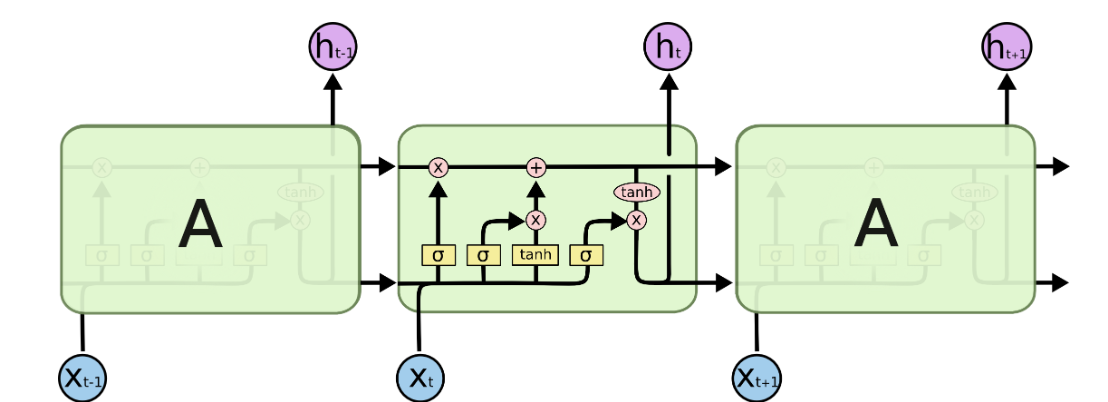





### LSTM Architecture

The key thing that makes LSTMs so powerful is the ***memory cell**, this is the horizontal line running through our diagram below. Think of the memory cell as conveyor belt that runs across the network and where information can be stored long-term and remains 'unchanged' (unless done so by the gates). This is the long-term memory of the network.

The information that is added, removed or updated into our long-term memory (the cell state), is controlled by 3 gates. Gates are a way to selectively let information into and out of the cell state, they are composed of activation functions (sigmoid/tanh) and elementwise multiplications of input values.

- **Forget gate**: Determines what information is removed from the cell state
- **Input gate**: Determines what information is added to the cell state
- **Output gate**: Controls what information is output from the cell state

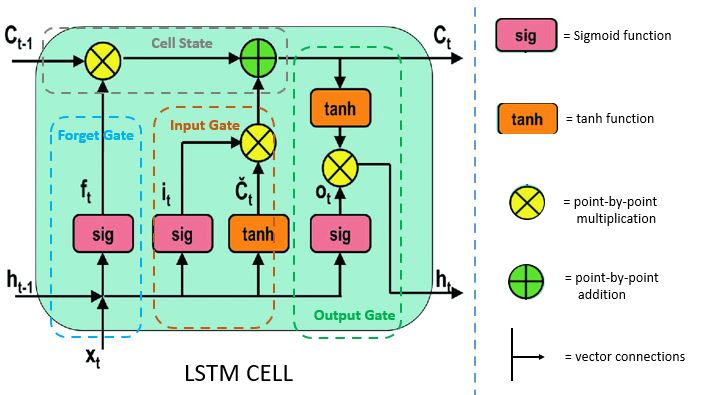

### Step-by-step walkthrough of LSTMs

##### 1. The Forget Gate


The first step of the LSTM is to decide what information is going to be 'forgotten' in our cell memory - what is being removed from the cell state. This decision is made by a sigmoid layer called the “forget gate layer.” It looks at (H<sub>t-1</sub>) and (x<sub>t</sub>) and outputs a number between 0 and 1. For each item in the cell state, (C<sub>t-1</sub>), if an item get 0 it is forgoten from the cell state and if 1 , it is kept.


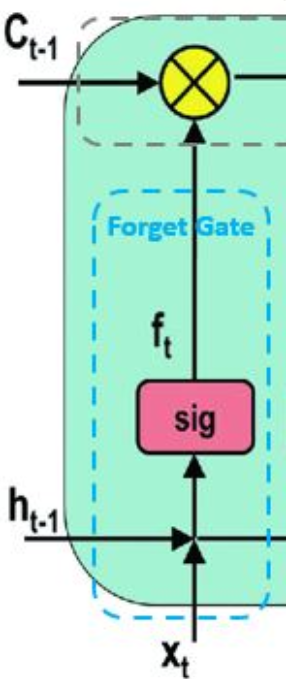



Let's say you have the sentence. ***Mercy is tall, but Dorice is _____***

#### 2. The Input Gate

The input  gate decides which information will be added to the cell state. It does this in 2 stages, it uses the sigmoid function to decide which values are important and also tanh function to update the information. In short, the input gate's job is to quantify the importance of the new information carried by the input.

The input data (x<sub>t</sub>) at the current time step and the hidden state (H<sub>t-1</sub>) of the previous time step are in parallel fed through a sigmoid and tanh layer. The sigmoid layer decides how important the incoming information is, while the tanh layer defines the magnitude of the candidate values. The output of both the sigmoid (important) and the tanh (flavor/meaning) are combined and sent to the cell state.

Let me use an example and not the math to make this make sense, imagine the sentence
"The tall man walked into the room..."

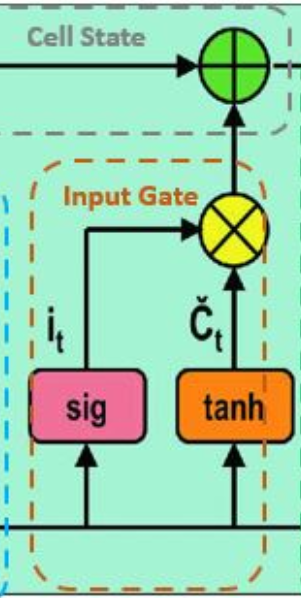


***Key takeaway: The input gate decides which words deserve long-term real estate in the network’s memory***

#### 3. The Output gate

The output gate is responsible for deciding what part of the current cell state should be sent as the hidden state (output) for this time step.First, the gate uses a sigmoid function to determine which information from the current cell state will be output. 

Just like the input gate, the output gate has 2 layers... the sigmoid layer and the tanh layer, and they both run in parallel.The model looks at the current input (x<sub>t</sub>)  and the previous hidden state (H<sub>t-1</sub>)  and runs them through a sigmoid function. Think of it this way, the sigmoid functions helps us decide which parts of the cell state are relevant given the current hidden state and input. What is useful NOW?. The tanh layer just prepares the memoery by squaishing it between -1 and 1, making it more stable.


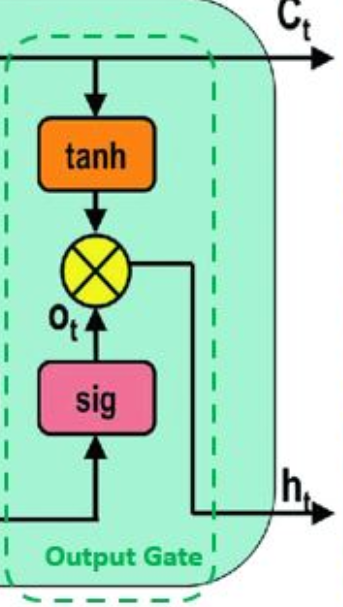


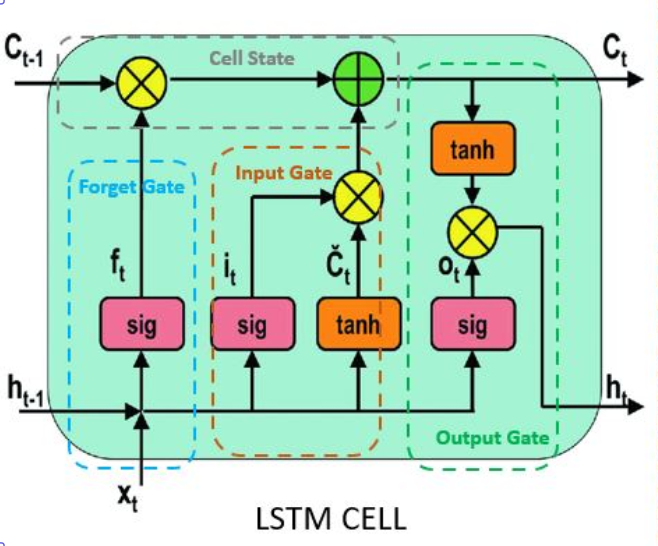

## Time Series Analysis Practicum

In [151]:
#import all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
#import the dataset
data=pd.read_csv(r"D:\Advanced_Machine_Learning\datasets\AirPassengers.csv")
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [153]:
#check the data for correct datatypes and null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


Change the Month column into a date time object and make the time component the index of your dataset.

In [154]:
data['Month']=pd.to_datetime(data['Month'],errors='coerce',dayfirst=False)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [155]:
data.set_index('Month',inplace=True)
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


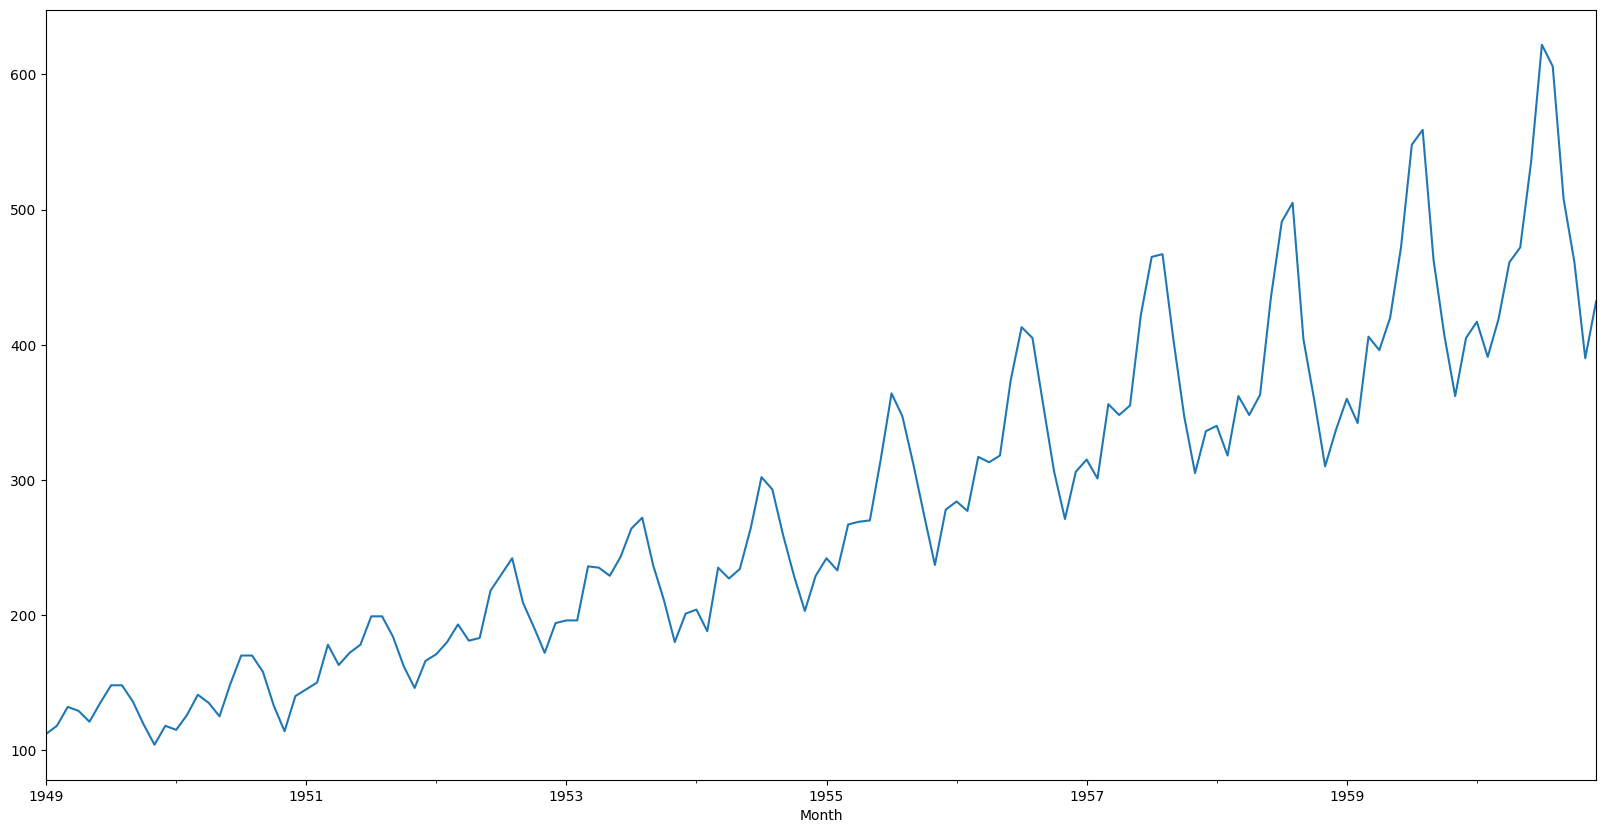

In [156]:
plt.figure(figsize=(20,10))
data['#Passengers'].plot()
plt.show()

#### Initial Insights about our Time-Series - Student led

* Time series has a trend
* Time series has seasonality- changes occur within a year
* Therefore our time-series is non-stationary.

##### Perform your time series decomposition

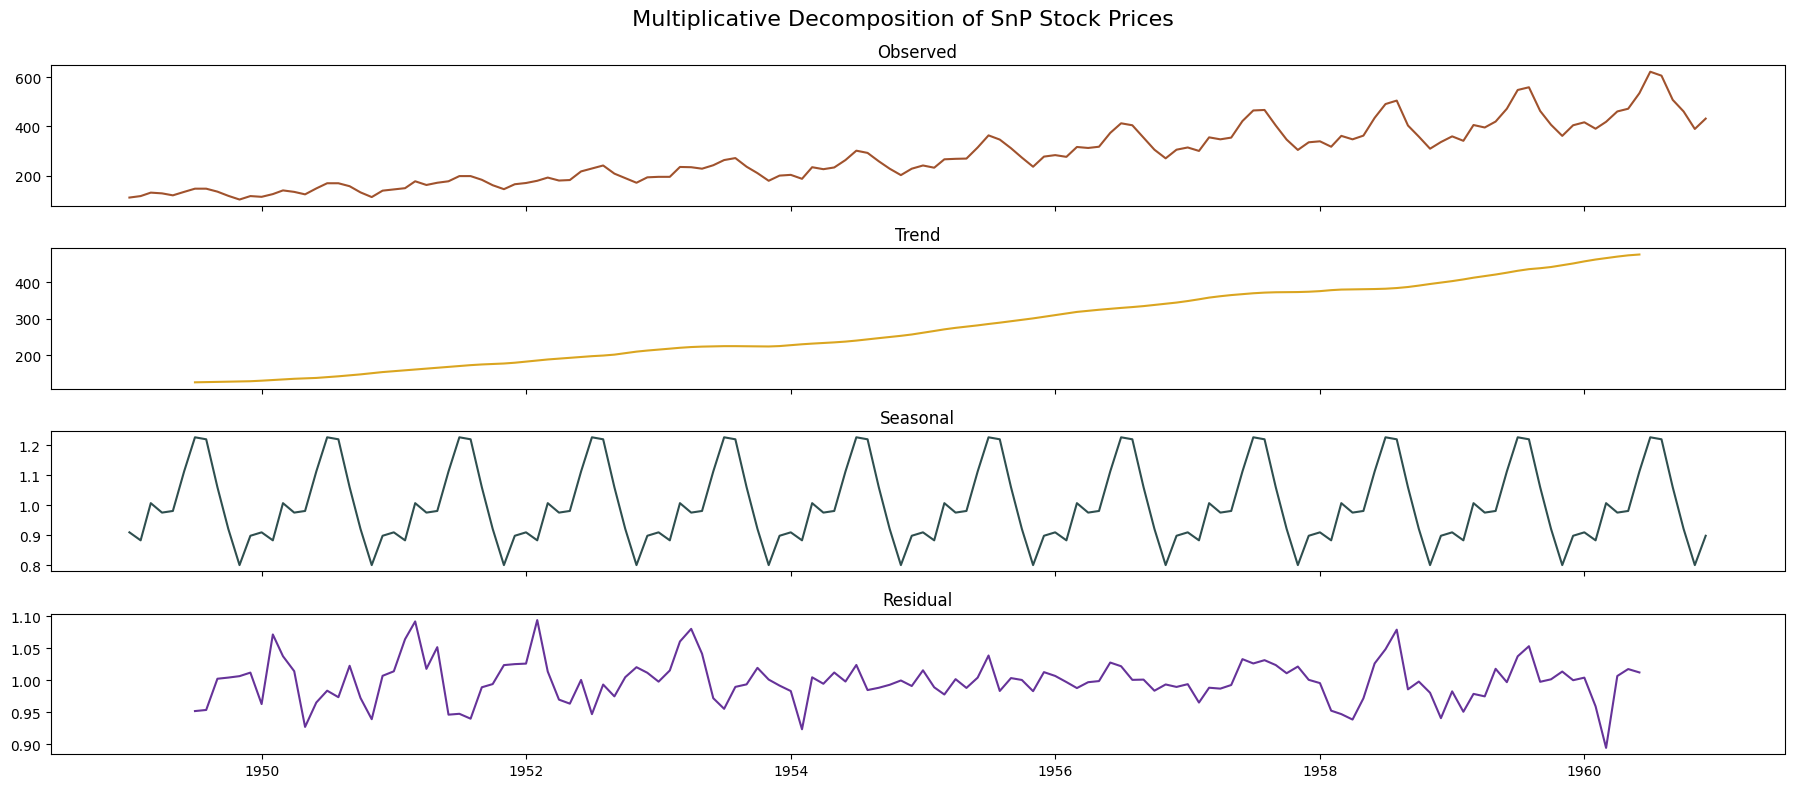

In [157]:
from statsmodels.tsa.seasonal import seasonal_decompose


result = seasonal_decompose(data['#Passengers'], model='multiplicative', period=12)

# Plot and save classical decomp components
fig, axs = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle(' Multiplicative Decomposition of SnP Stock Prices', fontsize=16)
plt.tight_layout()

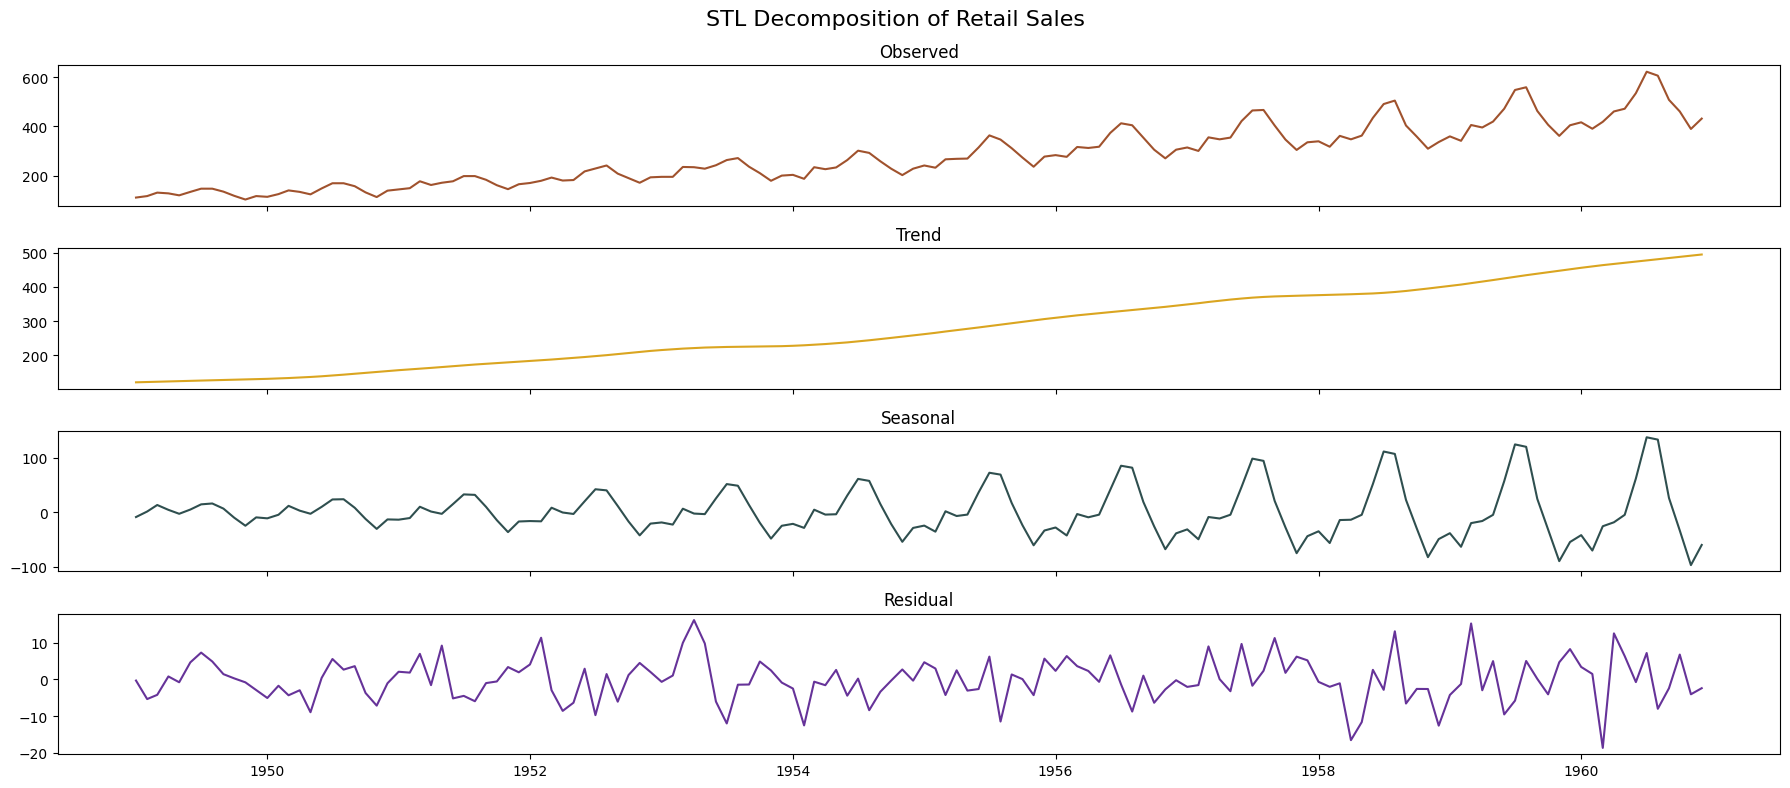

In [158]:
# Apply STL decomposition


from statsmodels.tsa.seasonal import STL

stl = STL(data['#Passengers'], seasonal=13)
result = stl.fit()

# Plot and save STL components
fig, axs = plt.subplots(4, 1, figsize=(18, 8), sharex=True)

axs[0].plot(result.observed, color='sienna')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='goldenrod')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkslategrey')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='rebeccapurple')
axs[3].set_title('Residual')

plt.suptitle('STL Decomposition of Retail Sales', fontsize=16)
plt.tight_layout()
plt.show()

### Insights from Time Series Decomposition (Student -led)

#### Check for stationarity

In [64]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['#Passengers'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

# Decision based on p-value
if result[1] <= 0.05:
    print("Reject the null hypothesis (H0). The time series is stationary.")
else:
    print("The p values is more than 0.05,Fail to reject the null hypothesis (H0). The time series is non-stationary.")

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Critical Values:
	1%: -3.4816817173418295
	5%: -2.8840418343195267
	10%: -2.578770059171598
The p values is more than 0.05,Fail to reject the null hypothesis (H0). The time series is non-stationary.


### Data Pre-processing

The time series decomposition using STL and the ADF test, have confirmed that our time series is non-stationary, this for one, gives us direction for which time series models we can use and the pre-processing steps we need before model training.



In [65]:
# this step is only applied to the train set to avoid data leakage

split_point = int(len(data['#Passengers']) * 0.8)  

train= data['#Passengers'].iloc[:split_point] # Data used for fitting
test= data['#Passengers'].iloc[split_point:]   # Data used for evaluating forecasts

print(f"Total data points: {len(data)}")
print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

Total data points: 144
Training data points: 115
Testing data points: 29


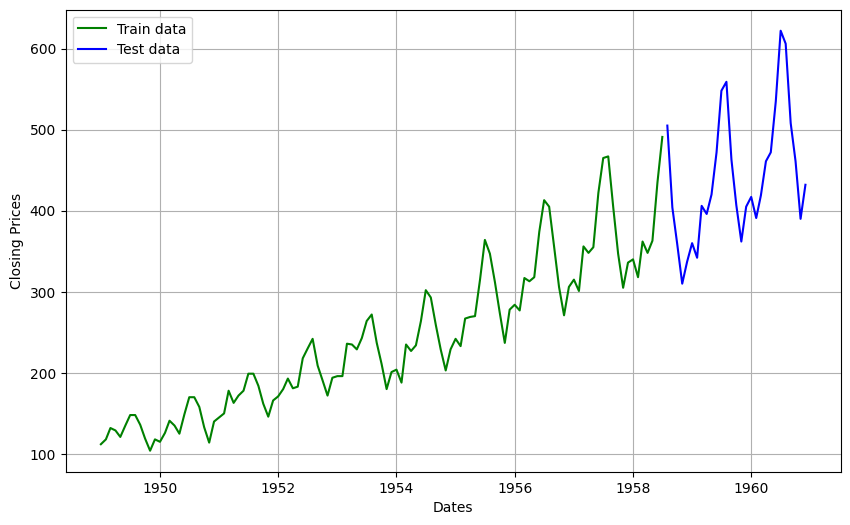

In [66]:
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train, 'green', label='Train data')
plt.plot(test, 'blue', label='Test data')
plt.legend()

In [67]:
train.head()

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64

In [81]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

log_series = np.log(train)

# Remove seasonality and trend 
log_diff = log_series.diff(12).diff(1).dropna()


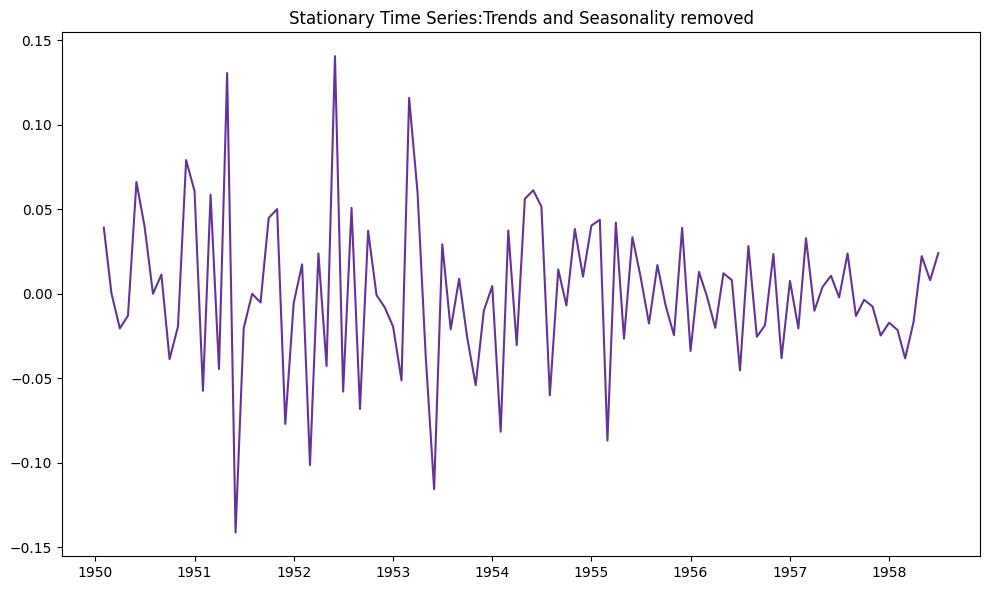

In [83]:
plt.figure(figsize=(10,6))

plt.plot(log_diff, color='rebeccapurple')
plt.title('Stationary Time Series:Trends and Seasonality removed')
plt.tight_layout()
plt.show()

### Autocorrelation

<Figure size 4000x300 with 0 Axes>

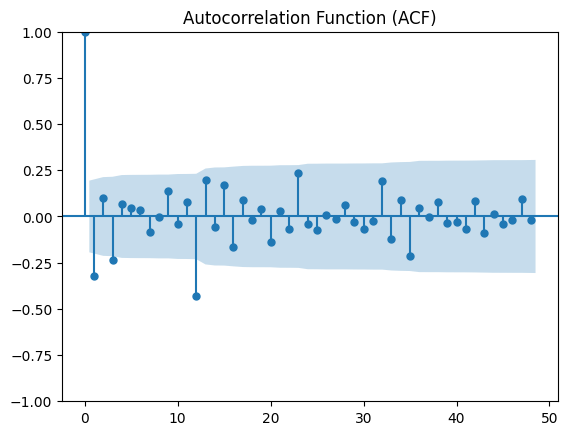

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plt.figure(figsize=(40,3))

# Plot ACF
plot_acf(log_diff,lags=48,title='Autocorrelation Function (ACF)')
plt.show()

<Figure size 1000x100 with 0 Axes>

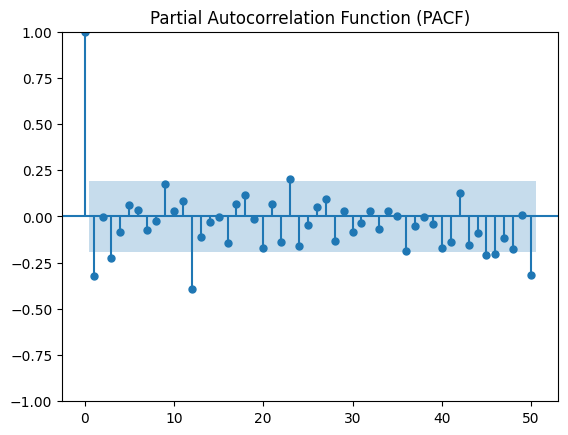

In [86]:
plt.figure(figsize=(10, 1))

# Plot PACF
plot_pacf(log_diff,method='ols',lags=50,title='Partial Autocorrelation Function (PACF)')
plt.show()

#### Insights from ACF/PACF plot

Use Auto-ARIMA to confirm the manual checks from ACF/PACF

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-335.753, Time=0.18 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-365.460, Time=0.97 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-372.171, Time=1.30 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-345.397, Time=0.11 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-370.441, Time=1.58 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-370.509, Time=1.33 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-366.182, Time=1.61 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-368.344, Time=3.15 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-364.570, Time=0.51 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-369.862, Time=1.21 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=-370.241, Time=1.39 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-371.865, Time=0.95 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=-368.578, Time=2.58 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=-370.207, Time=4.31 sec

Best model:  ARIMA

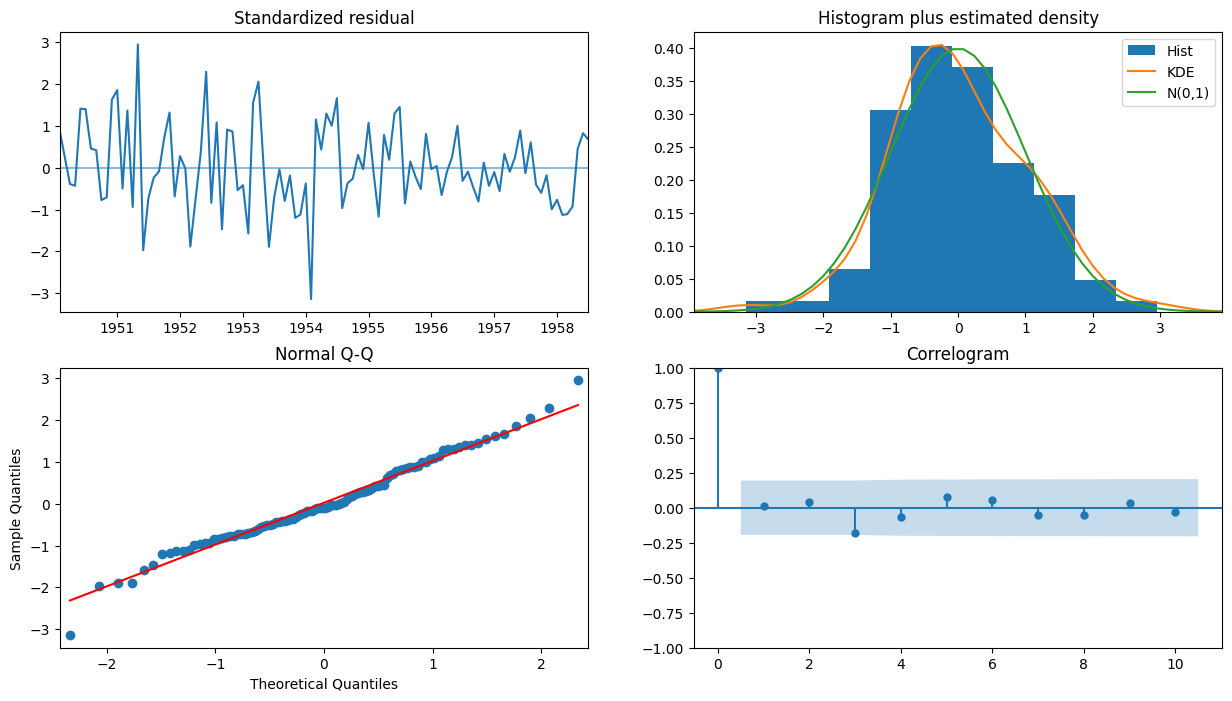

In [91]:
from pmdarima.arima import auto_arima
model_autoARIMA = auto_arima(
                     log_series, 
                     start_p=0, start_q=0,
                     start_P=0, start_Q=0,
                     max_p=5, max_q=5,
                     max_P=3, max_Q=3,
                     m=12,              
                     d=1, 
                     D=1,         
                     seasonal=True,   
                     trace=True,
                     error_action='ignore',  
                     suppress_warnings=True, 
                     information_criterion='aic',
                     stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

#### Insights from the Auto-ARIMA

Now we fit a SARIMAX model, using the parameters we just learned

In [93]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    log_series,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=True)
print(sarima_fit.summary())

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  115
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 164.875
Date:                            Wed, 15 Apr 2026   AIC                           -323.749
Time:                                    12:00:44   BIC                           -316.317
Sample:                                01-01-1949   HQIC                          -320.755
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3528      0.096     -3.679      0.000      -0.541      -0.165
ma.S.L12      -0.5581      0.109   

#### Residual Diagnosis

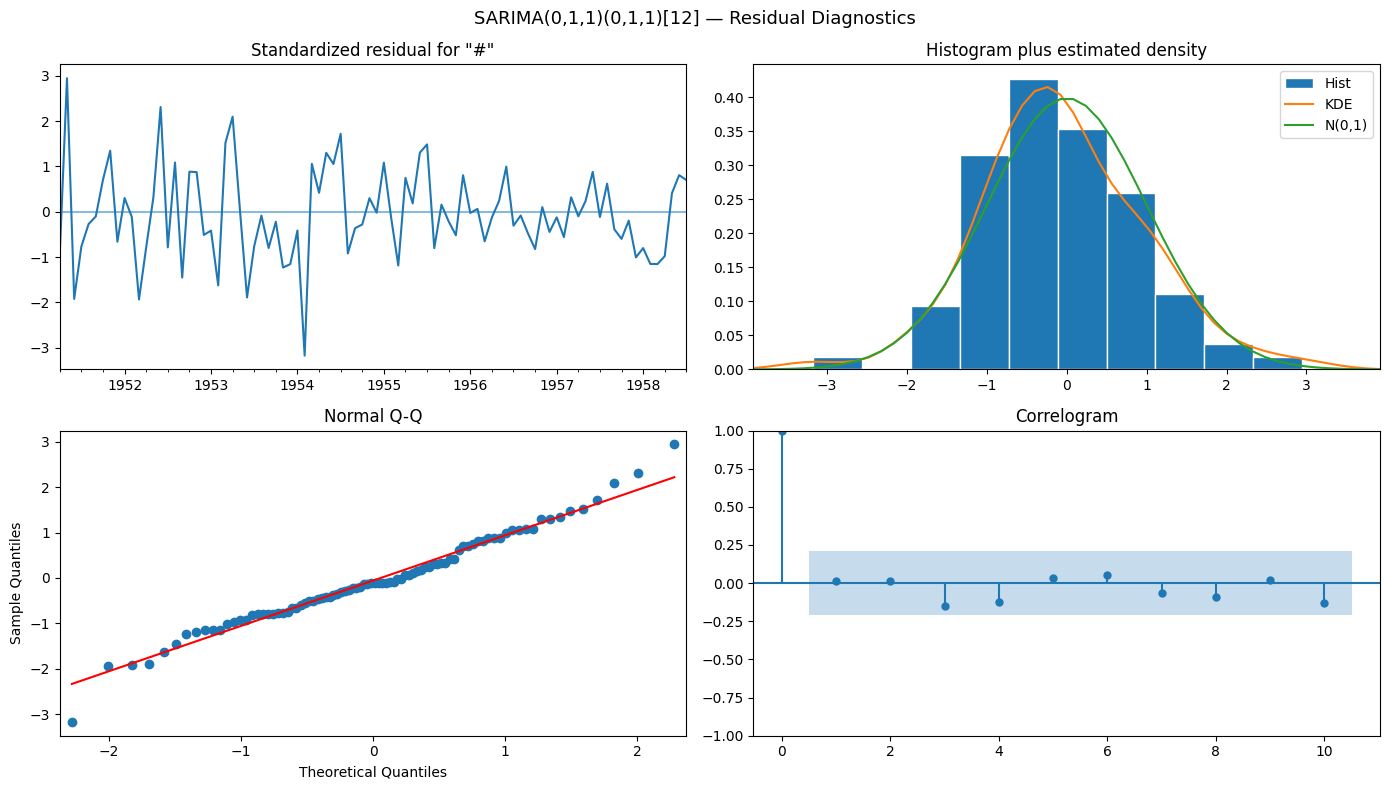

In [94]:
sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA(0,1,1)(0,1,1)[12] — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

#### Interpretation of residual diagnostics - Student led

### Forecasting and Model Evaluation

In [95]:
# Get the number of steps to forecast
n_forecast = len(test)

# forecast in log space
forecast_test = sarima_fit.forecast(steps=n_forecast)

# Remember we fit on log  train data, so we reverse it to get the actual # passengers forecast
forecast = np.exp(forecast_test)
forecast.index = test.index



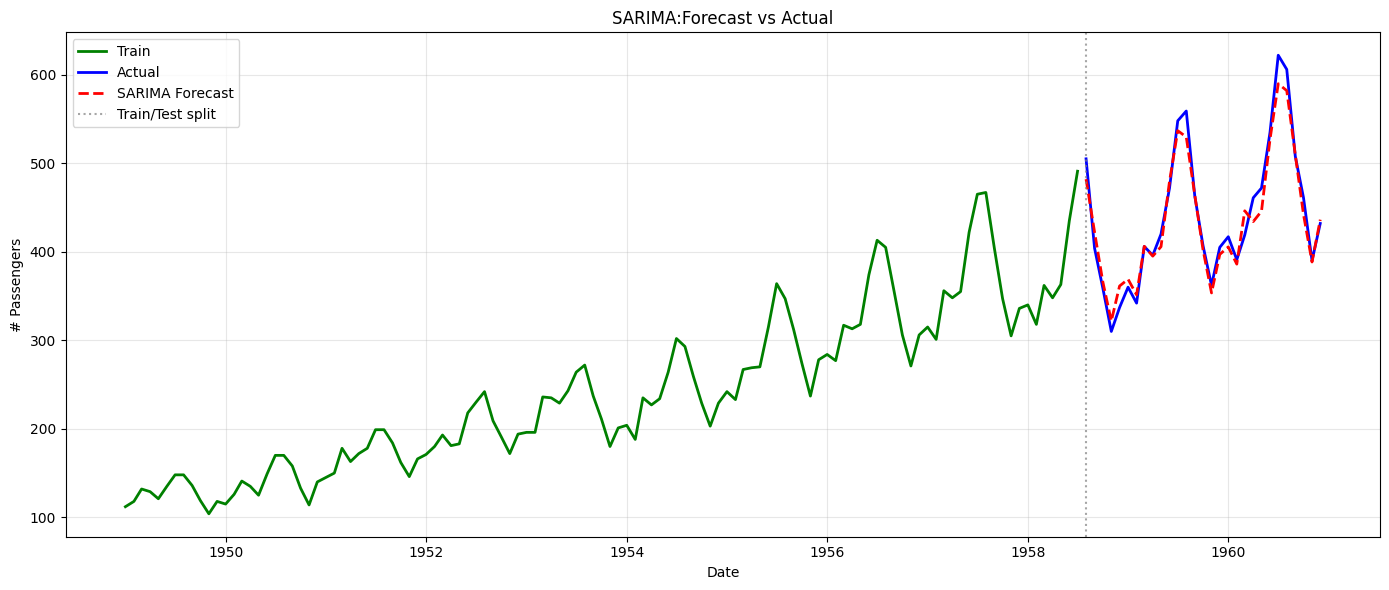

In [96]:
# plot the results

plt.figure(figsize=(14, 6))

plt.plot(train, color='green',  linewidth=2,   label='Train')
plt.plot(test,  color='blue',   linewidth=2,   label='Actual')
plt.plot(forecast, color='red', linewidth=2,linestyle='--',label='SARIMA Forecast')
plt.axvline(test.index[0], color='gray',linestyle=':', alpha=0.7,label='Train/Test split')

plt.title('SARIMA:Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('# Passengers')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae  = mean_absolute_error(test,forecast)
rmse = math.sqrt(mean_squared_error(test,forecast))


print('SARIMA Performance')
print(f'  MAE  : {mae:.2f}')
print(f'  RMSE : {rmse:.2f}')

SARIMA Performance
  MAE  : 12.95
  RMSE : 16.16


## LSTMs for Time Series Analysis

Let us compare the performance of LSTM to SARIMA. There is a significant difference in data pre-processing,LSTMs only need your data to be scaled, log transformed (note, this is unique to this specific dataset, because it has a growing variance) and sequenced.

In [100]:
# scale your time series
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

print(f'Train_scaled: {len(train_scaled)} points')
print(f'Test_scaled: {len(test_scaled)} points')

Train_scaled: 115 points
Test_scaled: 29 points


In [118]:
import numpy as np

def create_dataset(dataset, window_size):
    X, y = [], []

    for i in range(len(dataset) - window_size):
        window=dataset[i : i + window_size]
        X.append(window)

        label=dataset[i + window_size]
        y.append(label)

    return np.array(X), np.array(y)

In [119]:
window_size = 12

X_train, y_train = create_dataset(train_scaled, window_size)
X_test,  y_test  = create_dataset(test_scaled,  window_size)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_test  shape: {y_test.shape}')

X_train shape: (103, 12, 1)
y_train shape: (103, 1)
X_test  shape: (17, 12, 1)
y_test  shape: (17, 1)


In [120]:
X_train = X_train.reshape(X_train.shape[0], window_size, 1)
X_test  = X_test.reshape(X_test.shape[0],  window_size, 1)

print(f'X_train reshaped: {X_train.shape}')
print(f'X_test  reshaped: {X_test.shape}')

X_train reshaped: (103, 12, 1)
X_test  reshaped: (17, 12, 1)


Now we can build our LSTM model...

In [122]:
X_train.shape[1]

12

In [123]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Build stacked LSTM
model = Sequential()
model.add(LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(128, return_sequences=False))
model.add(Dense(128,activation='relu'))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

d:\Advanced_Machine_Learning\adml-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 12, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 12, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,225 (1.05 MB)

 Trainable params: 276,225 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [124]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - loss: 0.7540 - mae: 0.7040 - val_loss: 2.7638 - val_mae: 1.4745
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2443 - mae: 0.3857 - val_loss: 1.1336 - val_mae: 0.7903
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2280 - mae: 0.3294 - val_loss: 2.4759 - val_mae: 1.3703
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1971 - mae: 0.3285 - val_loss: 0.7311 - val_mae: 0.6093
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1842 - mae: 0.3475 - val_loss: 1.1844 - val_mae: 0.8118
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1640 - mae: 0.3024 - val_loss: 1.1439 - val_mae: 0.7957
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1507 - mae: 0.3068 - val_loss: 0.9643 - val_mae: 0.7147
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1605 - mae: 0.3326 - val_loss: 0.9170 - val_mae: 0.6936
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1331 - mae:

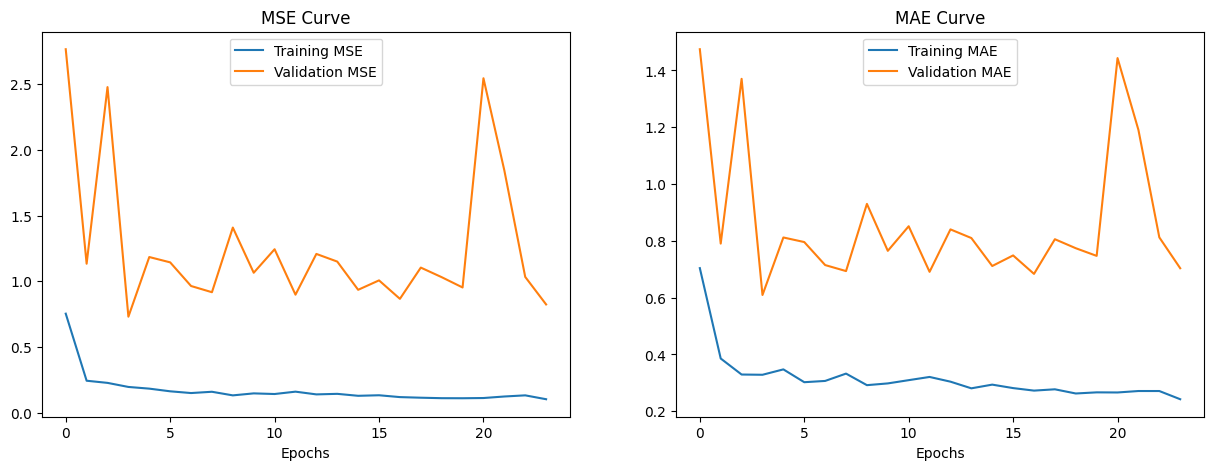

In [125]:
plt.figure(figsize=(15,5))

train_mse=history.history['loss']
val_mse=history.history['val_loss']

train_mae=history.history['mae']
val_mae=history.history['val_mae']

plt.subplot(121)
plt.plot(train_mse,label='Training MSE')
plt.plot(val_mse,label='Validation MSE')
plt.title('MSE Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_mae,label='Training MAE')
plt.plot(val_mae,label='Validation MAE')
plt.title('MAE Curve')
plt.xlabel('Epochs')
plt.legend()



#### Insights from Model Training- Learning curves- Do we have a high bias or high variance model?

In [141]:
#implement dropping layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build stacked LSTM
model = Sequential()
model.add(LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 12, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,169 (90.50 KB)

 Trainable params: 23,169 (90.50 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.8044 - mae: 0.7203 - val_loss: 4.9533 - val_mae: 2.0706
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.5605 - mae: 0.5781 - val_loss: 2.9932 - val_mae: 1.5321
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3172 - mae: 0.4172 - val_loss: 1.2505 - val_mae: 0.8296
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2060 - mae: 0.3636 - val_loss: 0.8709 - val_mae: 0.6613
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2184 - mae: 0.3768 - val_loss: 1.0768 - val_mae: 0.7530
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2494 - mae: 0.3846 - val_loss: 1.6489 - val_mae: 1.0133
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1874 - mae: 0.3519 - val_loss: 1.6625 - val_mae: 1.0201
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2659 - mae: 0.3831 - val_loss: 1.5768 - val_mae: 0.9834
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2493 - mae:

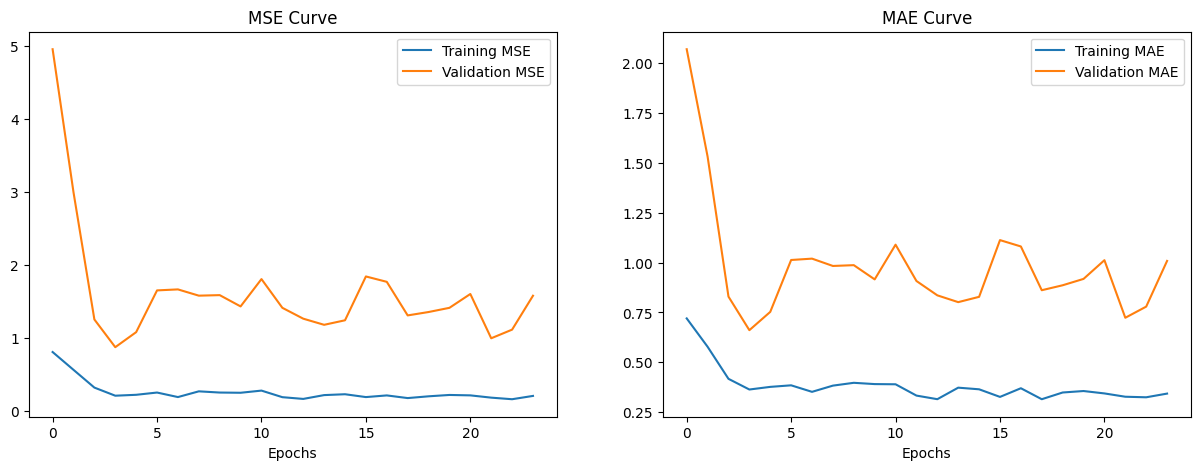

In [143]:
plt.figure(figsize=(15,5))

train_mse=history.history['loss']
val_mse=history.history['val_loss']

train_mae=history.history['mae']
val_mae=history.history['val_mae']

plt.subplot(121)
plt.plot(train_mse,label='Training MSE')
plt.plot(val_mse,label='Validation MSE')
plt.title('MSE Curve')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(122)
plt.plot(train_mae,label='Training MAE')
plt.plot(val_mae,label='Validation MAE')
plt.title('MAE Curve')
plt.xlabel('Epochs')
plt.legend()



In [148]:
# predict on unseen test data and transform back to original numeric values for evaluation
test_predict = model.predict(X_test)
test_predict = scaler.inverse_transform(test_predict)
y_observed = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train= scaler.inverse_transform(y_train.reshape(-1, 1))



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [149]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

mae  = mean_absolute_error(y_observed, test_predict)
rmse = math.sqrt(mean_squared_error(y_observed, test_predict))


print('LSTM Performance')
print(f'  MAE  : {mae:.2f}')
print(f'  RMSE : {rmse:.2f}')


LSTM Performance
  MAE  : 60.14
  RMSE : 84.88


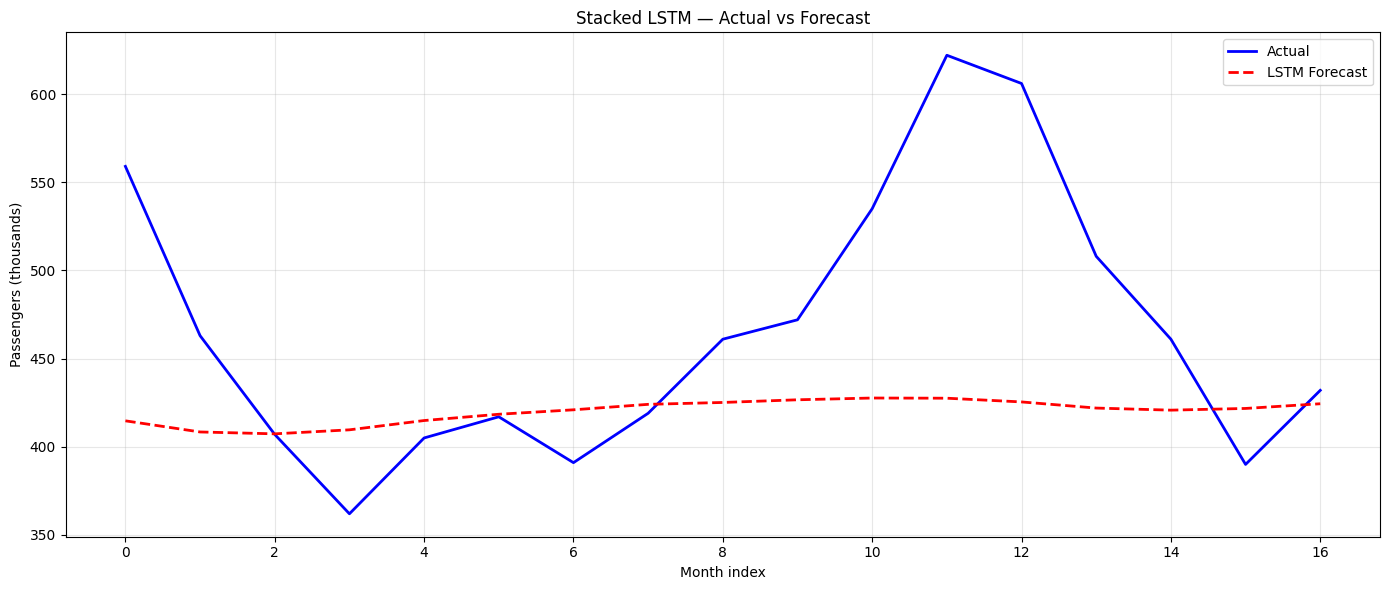

In [147]:
plt.figure(figsize=(14, 6))
plt.plot(y_observed, color='blue',linewidth=2, label='Actual')
plt.plot(test_predict,  color='red',linewidth=2,linestyle='--',label='LSTM Forecast')
plt.title('Stacked LSTM — Actual vs Forecast')
plt.xlabel('Month index')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Insights- student led...